In [123]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [124]:
class batsmanState(TypedDict):
    run:int
    balls:int
    fours:int
    sixs:int 

    strike_rate:float
    bpb:float
    boundry_percentage:float
    summary:str


In [125]:
def SR_calculator(state:batsmanState)->batsmanState:
    balls= state['balls']
    runs=state['run']
    sr=(runs / balls) * 100
    return {'strike_rate':sr}
    

In [126]:
def bpb_calculator(state:batsmanState)->batsmanState:
    balls= state['balls']
    fours=state['fours']
    sixe=state["sixs"]
    
    total_boundaries = fours + sixe
    bpb = balls / total_boundaries
    
    return {'bpb':bpb}

In [127]:
def boundry_percentage(state:batsmanState)->batsmanState:
    fours=state['fours']
    sixe=state["sixs"]
    run=state['run']
    boundary_runs = (fours * 4) + (sixe * 6)
    percentage=(boundary_runs / run) * 100
    return {'boundry_percentage':percentage}

In [128]:
def summary(state:batsmanState)->batsmanState:
    summary=f"""strite rate : {state['strike_rate']}\n
            ball per boundry :{state['bpb']}\n
            percentage boundry :{state['boundry_percentage']}
    """
    state['summary']=summary
    return {'summary':summary}


In [129]:
graph=StateGraph(batsmanState)

In [130]:
graph.add_node("sr",SR_calculator)
graph.add_node("bpb",bpb_calculator)
graph.add_node("percentage",boundry_percentage)
graph.add_node("summary",summary)

In [131]:
graph.add_edge(START,"sr")
graph.add_edge(START,"bpb")
graph.add_edge(START,"percentage")

graph.add_edge("sr","summary")

graph.add_edge("bpb","summary")
graph.add_edge("percentage","summary")
graph.add_edge("summary",END)
workflow=graph.compile()

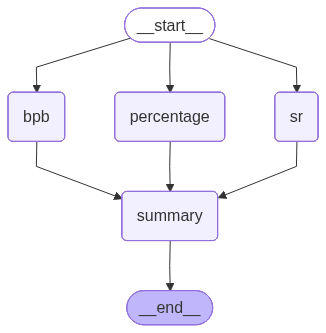

In [132]:
workflow

In [133]:
batsman_per = {
    "run": 50,
    "balls": 40,
    "fours": 5,
    "sixs": 3
}
workflow.invoke(batsman_per)


{'run': 50,
 'balls': 40,
 'fours': 5,
 'sixs': 3,
 'strike_rate': 125.0,
 'bpb': 5.0,
 'boundry_percentage': 76.0,
 'summary': 'strite rate : 125.0\n\n            ball per boundry :5.0\n\n            percentage boundry :76.0\n    '}